# Churn Analysis

What do the highest-risk customer segments look like?

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/customer_churn_cleaned.csv")

print("Shape:", df.shape)
print("Missing values:", df.isna().sum().sum())

Shape: (7250, 22)
Missing values: 0


# Identify the High-Risk Segment

We found in Notebook 03 that early-tenure + month-to-month + electronic check had high churn.

We are checking:

How many customers are in this segment?
How many churned?
What percentage churned?

In [2]:
high_risk = df[
    (df["Tenure"] <= 6) &
    (df["Contract"] == "Month-to-month") &
    (df["PaymentMethod"] == "Electronic check")
]

print("Customers in high-risk segment:", len(high_risk))
print("\nChurn distribution:")
print(high_risk["Churn"].value_counts())

print("\nChurn rate:")
print((high_risk["Churn"] == "Yes").mean() * 100)

Customers in high-risk segment: 420

Churn distribution:
Churn
Yes    236
No     184
Name: count, dtype: int64

Churn rate:
56.19047619047619


# Compare High-Risk Segment with Overall Customers

Now we know the segment has 420 customers and 56.19% churn.

We need to compare it with the overall churn rate (25.37%).

In [3]:
overall_churn_rate = (df["Churn"] == "Yes").mean() * 100
high_risk_churn_rate = (high_risk["Churn"] == "Yes").mean() * 100

print("Overall churn rate:", overall_churn_rate)
print("High-risk segment churn rate:", high_risk_churn_rate)
print("Difference:", high_risk_churn_rate - overall_churn_rate)

Overall churn rate: 25.365517241379308
High-risk segment churn rate: 56.19047619047619
Difference: 30.82495894909688


In [4]:
high_risk_summary = pd.DataFrame({
    "Metric": [
        "Customers",
        "Churned Customers",
        "Churn Rate",
        "Overall Churn Rate",
        "Difference"
    ],
    "Value": [
        len(high_risk),
        (high_risk["Churn"] == "Yes").sum(),
        high_risk_churn_rate,
        overall_churn_rate,
        high_risk_churn_rate - overall_churn_rate
    ]
})

high_risk_summary

,Metric,Value
0,Customers,420.000000
1,Churned Customers,236.000000
2,Churn Rate,56.190476
3,Overall Churn Rate,25.365517
4,Difference,30.824959


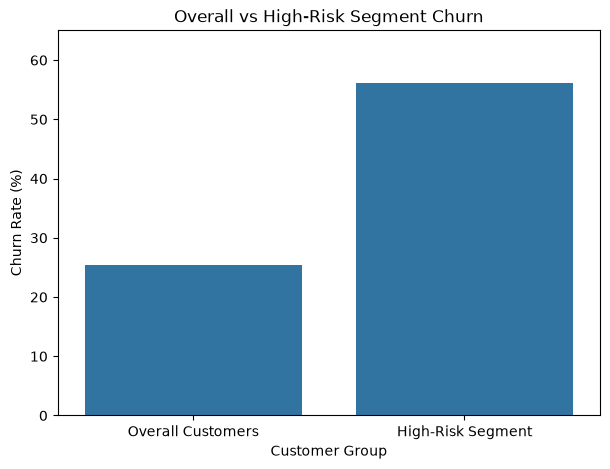

In [5]:
comparison = pd.Series({
    "Overall Customers": overall_churn_rate,
    "High-Risk Segment": high_risk_churn_rate
})

plt.figure(figsize=(7, 5))

sns.barplot(
    x=comparison.index,
    y=comparison.values
)

plt.title("Overall vs High-Risk Segment Churn")
plt.xlabel("Customer Group")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 65)
plt.show()

Of all customers who actually churned, what percentage came from this high-risk segment?

In [6]:
total_churned = (df["Churn"] == "Yes").sum()
high_risk_churned = (high_risk["Churn"] == "Yes").sum()

high_risk_share_of_churned = (
    high_risk_churned / total_churned
) * 100

print("Total churned customers:", total_churned)
print("High-risk segment churned customers:", high_risk_churned)
print("High-risk segment share of total churn:", high_risk_share_of_churned)

Total churned customers: 1839
High-risk segment churned customers: 236
High-risk segment share of total churn: 12.833061446438283


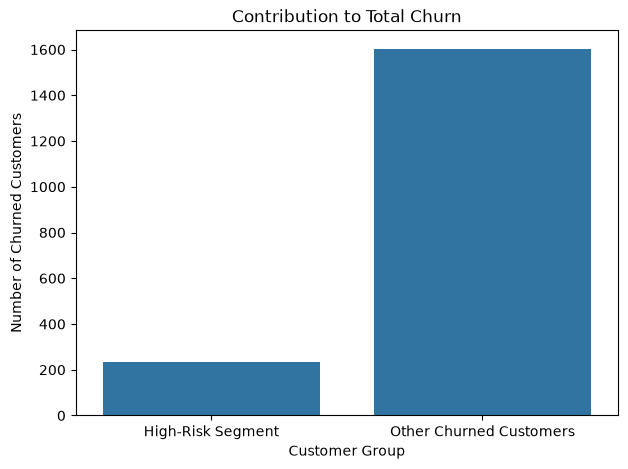

In [7]:
churn_contribution = pd.Series({
    "High-Risk Segment": high_risk_churned,
    "Other Churned Customers": total_churned - high_risk_churned
})

plt.figure(figsize=(7, 5))

sns.barplot(
    x=churn_contribution.index,
    y=churn_contribution.values
)

plt.title("Contribution to Total Churn")
plt.xlabel("Customer Group")
plt.ylabel("Number of Churned Customers")
plt.show()

The high-risk segment contains 420 customers, of whom 236 churned.

Those 236 customers represent 12.83% of all 1,839 churned customers.

## Conclusion

The high-risk segment of customers with **0–6 months tenure, month-to-month contracts, and electronic-check payment** contains 420 customers.

* Churned customers: **236**
* Segment churn rate: **56.19%**
* Overall churn rate: **25.37%**
* Share of total churn: **12.83%**

This segment has a substantially higher observed churn rate than the overall customer base and represents a meaningful portion of total churn.

Therefore, this segment can be considered a priority for further retention analysis and targeted retention strategies.


In [9]:
high_risk_summary.to_csv(
    "../outputs/tables/high_risk_segment_summary.csv",
    index=False
)

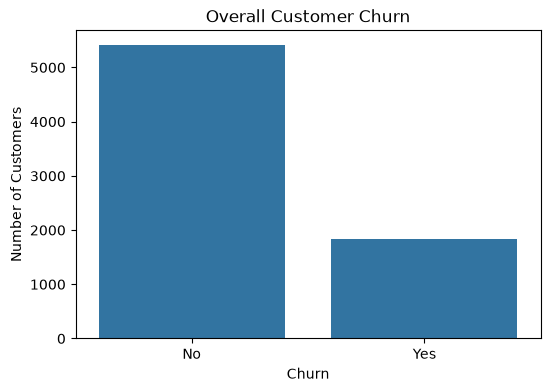

In [11]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6, 4))

sns.barplot(
    x=churn_counts.index,
    y=churn_counts.values
)

plt.title("Overall Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.savefig("../outputs/charts/overall_customer_churn.png",
            bbox_inches="tight")

plt.show()

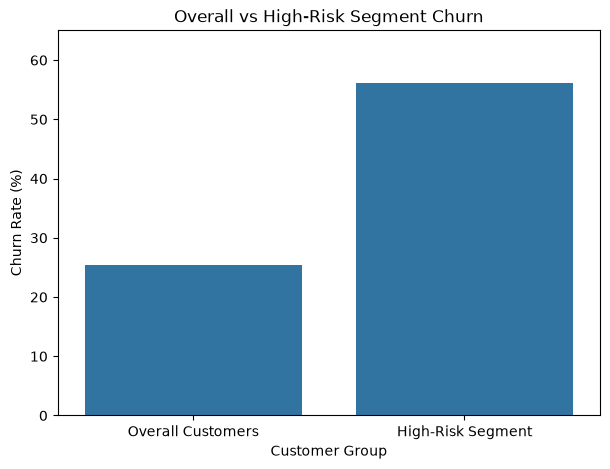

In [12]:
comparison = pd.Series({
    "Overall Customers": overall_churn_rate,
    "High-Risk Segment": high_risk_churn_rate
})

plt.figure(figsize=(7, 5))

sns.barplot(
    x=comparison.index,
    y=comparison.values
)

plt.title("Overall vs High-Risk Segment Churn")
plt.xlabel("Customer Group")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 65)

plt.savefig("../outputs/charts/overall_vs_high_risk_churn.png",
            bbox_inches="tight")

plt.show()

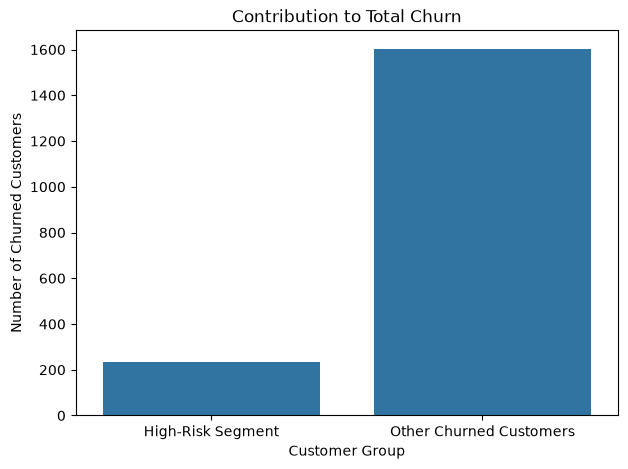

In [13]:
churn_contribution = pd.Series({
    "High-Risk Segment": high_risk_churned,
    "Other Churned Customers": total_churned - high_risk_churned
})

plt.figure(figsize=(7, 5))

sns.barplot(
    x=churn_contribution.index,
    y=churn_contribution.values
)

plt.title("Contribution to Total Churn")
plt.xlabel("Customer Group")
plt.ylabel("Number of Churned Customers")

plt.savefig("../outputs/charts/churn_contribution.png",
            bbox_inches="tight")

plt.show()